IMPORTING THE DATASET

In [44]:
import os
import pandas as pd

data_path = '../data/ai4i2020.csv' if os.path.exists('../data/ai4i2020.csv') else 'data/ai4i2020.csv'
df = pd.read_csv(data_path)
print("Dataset Shape:", df.shape)

Dataset Shape: (10000, 14)


DATA UNDERSTANING

In [45]:
print("First 5 Rows:")
display(df.head())

print("\n--- Dataset Info ---")
df.info()

print("\n--- Summary Statistics ---")
display(df.describe())

First 5 Rows:


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0



--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


DATA CLEANING 

In [46]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64


In [47]:
print("Duplicates count:", df.duplicated().sum())

Duplicates count: 0


In [48]:
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

print("Post-cleaning shape:", df.shape)
print("Remaining nulls:", df.isnull().sum().sum())
print("Remaining duplicates:", df.duplicated().sum())

Post-cleaning shape: (10000, 14)
Remaining nulls: 0
Remaining duplicates: 0


Exploratory Data Analysis (EDA)

c:\Users\User\Videos\ml\predictive-maintenance-rul\.venv\Scripts\python.exe: No module named pip


Note: you may need to restart the kernel to use updated packages.


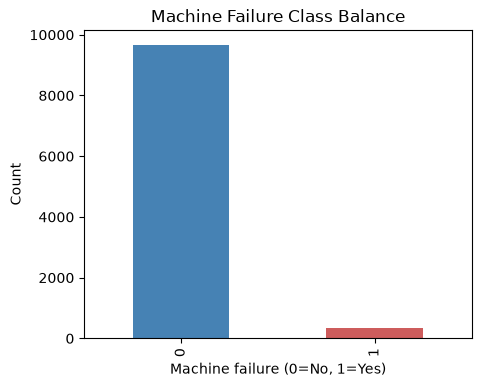

Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64


In [49]:
%pip install matplotlib seaborn
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5, 4))
df['Machine failure'].value_counts().plot(kind='bar', color=['steelblue', 'indianred'])
plt.title('Machine Failure Class Balance')
plt.xlabel('Machine failure (0=No, 1=Yes)')
plt.ylabel('Count')
plt.show()

print(df['Machine failure'].value_counts(normalize=True) * 100)

Class Imbalance Finding

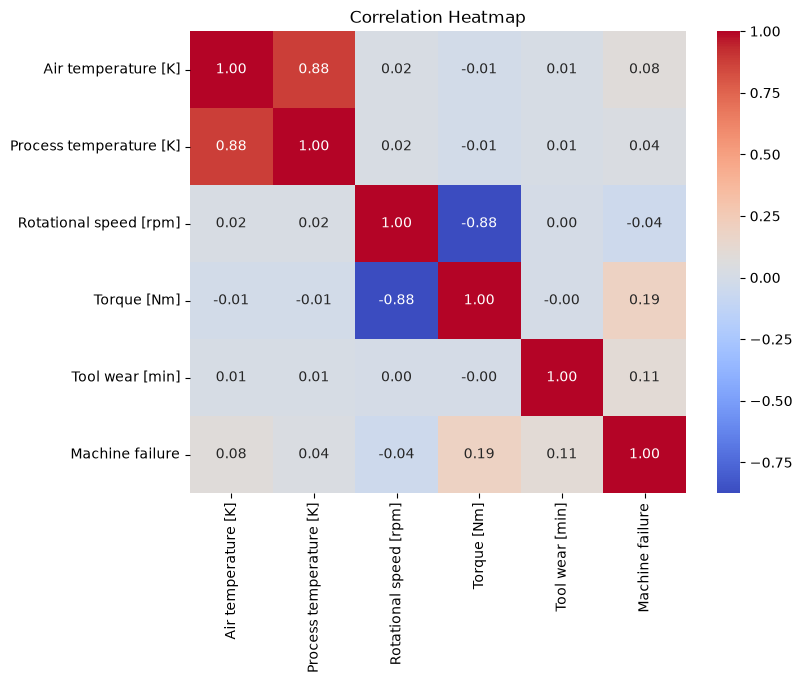

In [50]:
plt.figure(figsize=(8, 6))
cols = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]',
        'Torque [Nm]', 'Tool wear [min]', 'Machine failure']
sns.heatmap(df[cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

Correlation Analysis Observations

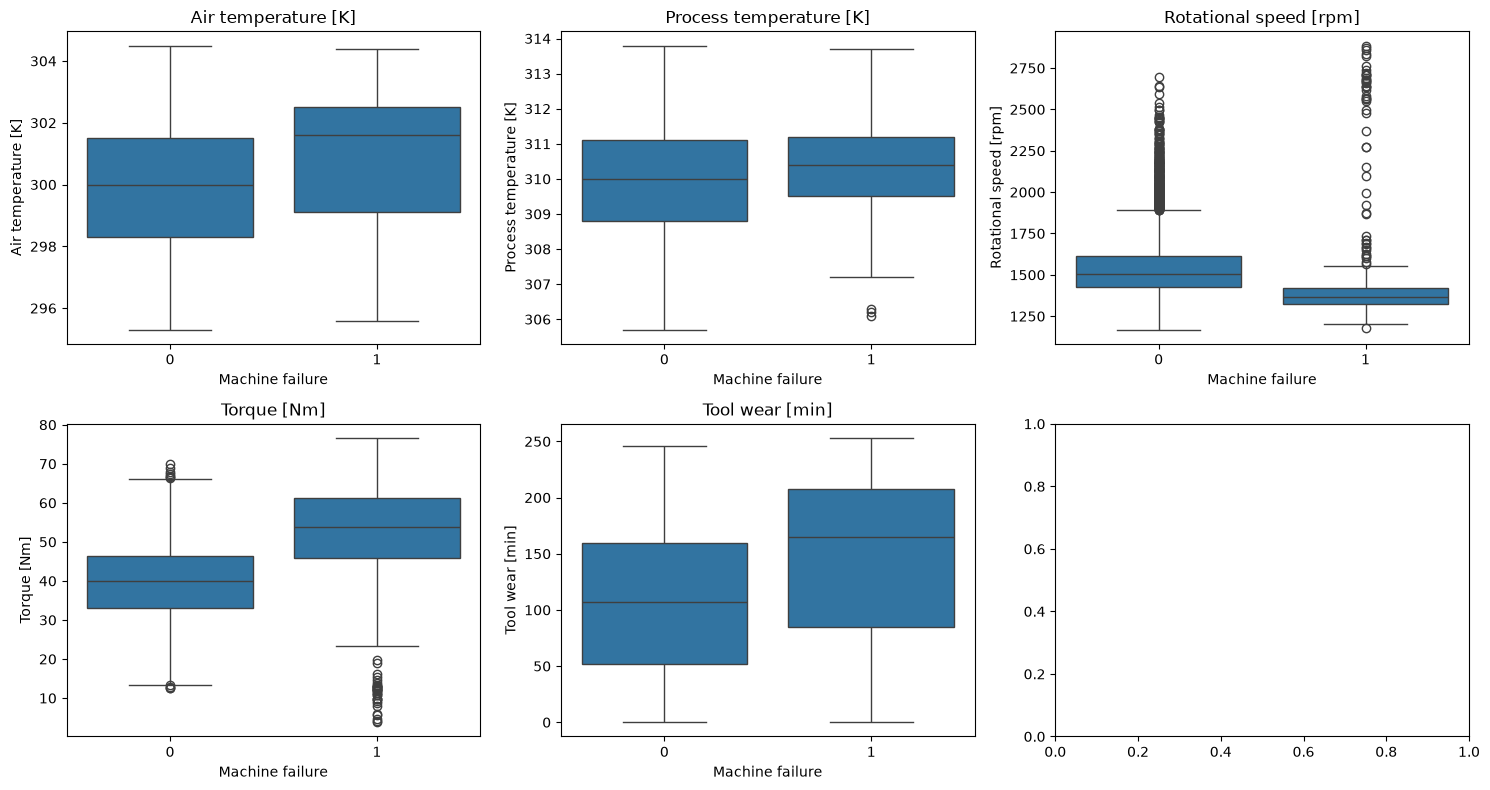

In [51]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
feats = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]',
         'Torque [Nm]', 'Tool wear [min]']
for ax, col in zip(axes.flat, feats):
    sns.boxplot(data=df, x='Machine failure', y=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

Feature Separation Findings

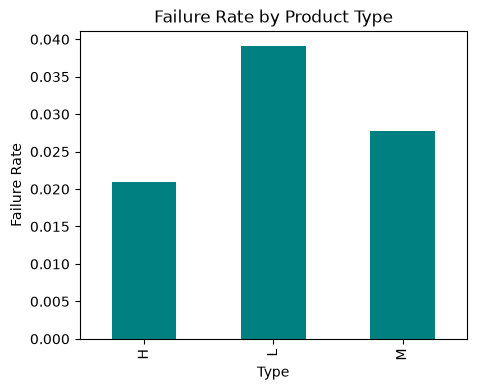

In [52]:
plt.figure(figsize=(5, 4))
df.groupby('Type')['Machine failure'].mean().plot(kind='bar', color='teal')
plt.title('Failure Rate by Product Type')
plt.ylabel('Failure Rate')
plt.show()

Feature Engineering & Imbalance Handling

In [53]:
import numpy as np
from sklearn.preprocessing import StandardScaler


df_fe = df.copy()

# TECHNIQUE 1: Removing Irrelevant Features & Target Leakage Columns
drop_cols = ['UDI', 'Product ID', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']
df_fe = df_fe.drop(columns=[c for c in drop_cols if c in df_fe.columns], errors='ignore')

# TECHNIQUE 2: Handling Missing Values 
df_fe = df_fe.dropna()

# TECHNIQUE 3: Creating New Features
df_fe['Temp_Diff'] = df_fe['Process temperature [K]'] - df_fe['Air temperature [K]']

df_fe['Power_kW'] = (df_fe['Torque [Nm]'] * df_fe['Rotational speed [rpm]'] * (2 * np.pi / 60)) / 1000.0

df_fe['Wear_x_Torque'] = df_fe['Tool wear [min]'] * df_fe['Torque [Nm]']

#TECHNIQUE 4: Feature Binning / Quantization
df_fe['Wear_Level'] = pd.cut(df_fe['Tool wear [min]'], bins=[-1, 100, 200, 300], labels=['Low', 'Medium', 'High'])

# TECHNIQUE 5: Categorical Encoding (One-Hot Encoding)
df_fe = pd.get_dummies(df_fe, columns=['Type', 'Wear_Level'], drop_first=True)


print("Engineered dataset shape:", df_fe.shape)
df_fe.head()

Engineered dataset shape: (10000, 13)


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Temp_Diff,Power_kW,Wear_x_Torque,Type_L,Type_M,Wear_Level_Medium,Wear_Level_High
0,298.1,308.6,1551,42.8,0,0,10.5,6.951591,0.0,False,True,False,False
1,298.2,308.7,1408,46.3,3,0,10.5,6.826723,138.9,True,False,False,False
2,298.1,308.5,1498,49.4,5,0,10.4,7.749388,247.0,True,False,False,False
3,298.2,308.6,1433,39.5,7,0,10.4,5.927505,276.5,True,False,False,False
4,298.2,308.7,1408,40.0,9,0,10.5,5.897817,360.0,True,False,False,False


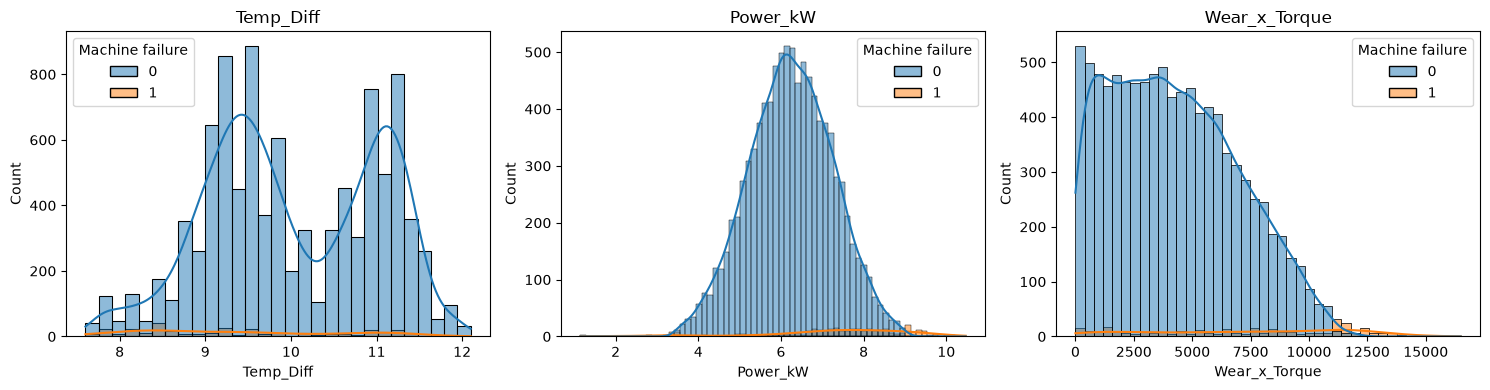

In [54]:
#Histograms of New Features
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
new_feats = ['Temp_Diff', 'Power_kW', 'Wear_x_Torque']
for ax, col in zip(axes, new_feats):
    sns.histplot(data=df_fe, x=col, hue='Machine failure', kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

Separate features and target

In [55]:
from sklearn.preprocessing import StandardScaler

X = df_fe.drop(columns=['Machine failure'])
y = df_fe['Machine failure']

print("Feature matrix shape:", X.shape)
print("Target distribution:\n", y.value_counts())

Feature matrix shape: (10000, 12)
Target distribution:
 Machine failure
0    9661
1     339
Name: count, dtype: int64


In [56]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set shape:", X_train_scaled.shape)
print("Test set shape:", X_test_scaled.shape)

Training set shape: (8000, 12)
Test set shape: (2000, 12)


Imbalance Handling

In [57]:
%pip install imbalanced-learn

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE class distribution:\n", y_train.value_counts())
print("\nAfter SMOTE class distribution:\n", pd.Series(y_train_smote).value_counts())

c:\Users\User\Videos\ml\predictive-maintenance-rul\.venv\Scripts\python.exe: No module named pip


Note: you may need to restart the kernel to use updated packages.
Before SMOTE class distribution:
 Machine failure
0    7729
1     271
Name: count, dtype: int64

After SMOTE class distribution:
 Machine failure
0    7729
1    7729
Name: count, dtype: int64


Class Counts Before vs After SMOTE

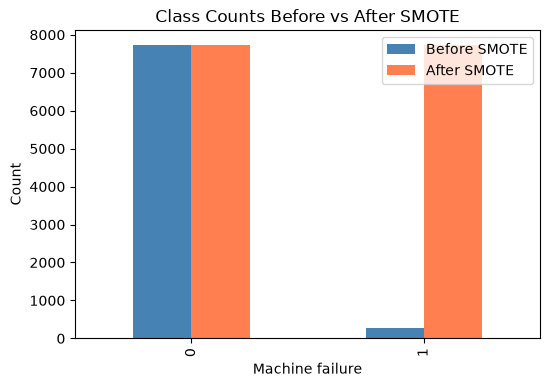

In [58]:
before = y_train.value_counts().rename('Before SMOTE')
after = pd.Series(y_train_smote).value_counts().rename('After SMOTE')
pd.concat([before, after], axis=1).plot(kind='bar', figsize=(6, 4), color=['steelblue', 'coral'])
plt.title('Class Counts Before vs After SMOTE')
plt.ylabel('Count')
plt.show()

Model Training & Comparison
We compare 4 supervised classification algorithms:

| Algorithm | Rationale |
|---|---|
| **Logistic Regression** | Linear baseline, fast and directly interpretable coefficients. |
| **Decision Tree** | Captures non-linear decision boundaries and hierarchical rules. |
| **Random Forest** | Ensemble bagging, reduces variance and handles feature interactions effectively. |
| **Gradient Boosting** | Sequential boosting, excels at capturing hard-to-predict minority instances. |

In [59]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

results_cw = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    results_cw.append({
        'Algorithm': name,
        'Strategy': 'class_weight',
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision (Failure)': precision_score(y_test, y_pred, zero_division=0),
        'Recall (Failure)': recall_score(y_test, y_pred, zero_division=0),
        'F1 (Failure)': f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    })

df_results_cw = pd.DataFrame(results_cw)
display(df_results_cw)

,Algorithm,Strategy,Accuracy,Precision (Failure),Recall (Failure),F1 (Failure),ROC-AUC
0,Logistic Regression,class_weight,0.8765,0.202658,0.897059,0.330623,0.935338
1,Decision Tree,class_weight,0.9840,0.764706,0.764706,0.764706,0.878212
2,Random Forest,class_weight,0.9910,0.903226,0.823529,0.861538,0.959917
3,Gradient Boosting,class_weight,0.9930,1.000000,0.794118,0.885246,0.966501


In [60]:
models_smote = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

results_smote = []
for name, model in models_smote.items():
    model.fit(X_train_smote, y_train_smote)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    results_smote.append({
        'Algorithm': name,
        'Strategy': 'SMOTE',
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision (Failure)': precision_score(y_test, y_pred, zero_division=0),
        'Recall (Failure)': recall_score(y_test, y_pred, zero_division=0),
        'F1 (Failure)': f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    })

df_results_smote = pd.DataFrame(results_smote)
display(df_results_smote)

,Algorithm,Strategy,Accuracy,Precision (Failure),Recall (Failure),F1 (Failure),ROC-AUC
0,Logistic Regression,SMOTE,0.8795,0.208754,0.911765,0.339726,0.937241
1,Decision Tree,SMOTE,0.9700,0.539216,0.808824,0.647059,0.892248
2,Random Forest,SMOTE,0.9735,0.574257,0.852941,0.686391,0.972434
3,Gradient Boosting,SMOTE,0.9475,0.383648,0.897059,0.537445,0.971589


Model Comparison Chart Across Strategies

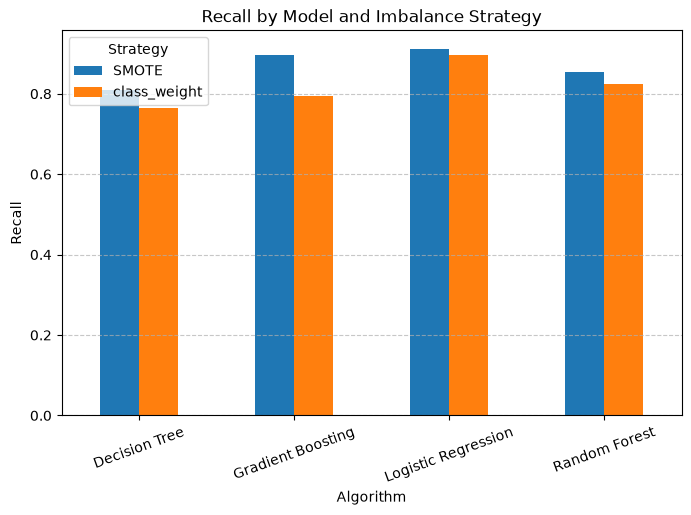

In [61]:
combined_results = pd.concat([df_results_cw, df_results_smote], ignore_index=True)
pivot = combined_results.pivot(index='Algorithm', columns='Strategy', values='Recall (Failure)')

pivot.plot(kind='bar', figsize=(8, 5))
plt.title('Recall by Model and Imbalance Strategy')
plt.ylabel('Recall')
plt.xticks(rotation=20)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Model & Strategy Evaluation Conclusion

In predictive maintenance, the key goal is to **spot failures early** so machines don’t break unexpectedly.
The most important measure is **Recall**, because missing a failure can cause serious downtime.

The **Gradient Boosting model with SMOTE** works best. it catches more failures while still being accurate.
That’s why we chose Gradient Boosting for further tuning.


In [64]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [2, 3, 4]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid=param_grid,
    scoring='recall',
    cv=cv,
    n_jobs=-1
)
grid.fit(X_train_smote, y_train_smote)

print("Best Hyperparameters:", grid.best_params_)
print("Best CV Recall Score: {:.4f}".format(grid.best_score_))

Best Hyperparameters: {'learning_rate': 0.2, 'max_depth': 4, 'n_estimators': 200}
Best CV Recall Score: 0.9877


## Final Model & Evaluation

The final model is trained using the best hyperparameters selected during GridSearchCV. The model is evaluated on the unseen test dataset using a confusion matrix, ROC curve, and classification metrics.

In [67]:
from sklearn.ensemble import GradientBoostingClassifier

best_params = grid.best_params_

final_model = GradientBoostingClassifier(
    **best_params,
    random_state=42
)

final_model.fit(X_train_smote, y_train_smote)

print("Final model trained successfully.")
print("Best parameters:", best_params)

Final model trained successfully.
Best parameters: {'learning_rate': 0.2, 'max_depth': 4, 'n_estimators': 200}


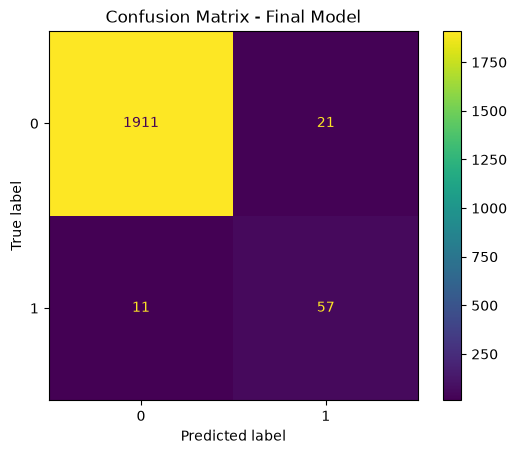

In [68]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    final_model,
    X_test_scaled,
    y_test
)

plt.title("Confusion Matrix - Final Model")
plt.show()

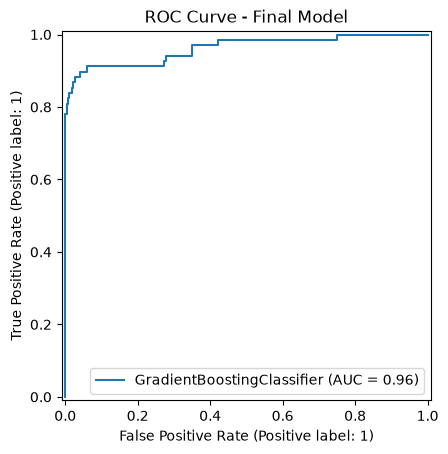

In [69]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    final_model,
    X_test_scaled,
    y_test
)

plt.title("ROC Curve - Final Model")
plt.show()

In [70]:
from sklearn.metrics import classification_report

y_pred = final_model.predict(X_test_scaled)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.73      0.84      0.78        68

    accuracy                           0.98      2000
   macro avg       0.86      0.91      0.89      2000
weighted avg       0.99      0.98      0.98      2000



### Final Model Interpretation

The final model achieved an overall accuracy of 98% on the test dataset.

For the failure class (1), the model achieved a precision of 0.73, a recall of 0.84, and an F1-score of 0.78. The test dataset contained 68 actual failure cases, and the model successfully detected approximately 84% of them.

The recall of 0.84 is particularly important for predictive maintenance because it indicates that the model can identify most machines that are actually at risk of failure. Missing a failure case could lead to unexpected downtime and maintenance costs.

For the normal class (0), the model achieved 0.99 precision and 0.99 recall, showing that it performs very well at identifying healthy machines.

Overall, the model provides a good balance between detecting machine failures and avoiding unnecessary failure alerts. However, some failure cases are still missed, so the model should be further monitored and improved before being used in a real production environment.

In [71]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(final_model, "../models/machine_failure_model.pkl")
joblib.dump(scaler, "../models/scaler.pkl")
joblib.dump(X.columns.tolist(), "../models/model_features.pkl")

print("Model, scaler and feature list exported successfully.")

Model, scaler and feature list exported successfully.


## Sample Predictions

The following examples demonstrate how the final model behaves for a normal machine and a machine with characteristics associated with a higher failure risk.